# DMS Regression Assignment

Author: <span style='background:blue; color:white;'>Gilberto Seedorf</span><br>
Student number: <span style='background:blue; color:white;'>655359</span><br>
Date: <span style='background:blue; color:white;'>15-02-2026</span>

-------------------------

In [1]:
# not all imports are used in this assignment
import pandas as pd
import matplotlib.pyplot as plt
import DMS_functions as dms
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from mpl_toolkits.mplot3d import Axes3D


## The Assignment

Your assignment is to complete this notebook. You will first need to find a dataset that is not used in this course. If you've done the homework, you should already have this.

Then you need to complete the rest of this notebook that consists is split into two parts.

1. Getting a Pass <br> This section must be completed to get a pass. If done properly you get a 70 max. It consists of three sub-sections
    1. *The Data* <br> In this chapter you describe the dataset you found (any dataset not used in the course) and select the variables you are going to use.
    2. *Bivariate Regression* <br> This chapter is about performing a bivariate regression analysis. You will do this twice. So first to predict y using variable 1, then to predict y using variable 2.
    3. *Multivariate Regression* <br> The last part is about combining the two variables you used to predict y, to see how well the prediction would be if you use both. <br>

2. Getting a 80-100 <br> This contains less structured sub-sections. You can choose which you want to do. Each is worth +10 with a maximum of 100. These will only be graded once the first part *Getting a Pass* is achieved.



You will need to complete the code cells, but also add the requested information in the <span style='background:blue; color:white;'>blue parts</span>.

Use the explanations given in this course, and rephrase those in your own words to answer them. You can use AI tools to clarify the given explanations in the course, but not to simply answer them for you. If questions are answered by AI this will be result in an automatic fail, and reported to the examboard.


<div style="background-color: #fff3cd; border-left: 6px solid #ffa502; padding: 10px;">
  <p style="color: #856404;">
    <p style="color: #856404;">❗❗❗EXPLANATIONS ARE EQUALLY IMPORTANT❗❗❗</p>
    <p style="color: #856404;">Only providing code is NOT enough. This course is more about understanding what you are doing then writing code!</p>
</div>

## Getting a Pass

You have to complete this part to get a pass.

### The Data

<span style='background:white; color:black;'>Describe what your dataset is about, and which variable you would like to predict (the outcome variable).</span>

This dataset contains information about red Portuguese “Vinho Verde” wine. It includes different physicochemical measurements of the wine, such as acidity levels, sugar content, density, sulphates, and alcohol percentage. These are the input variables, which describe measurable properties of the wine based on laboratory tests. The dataset also includes a sensory quality score, which is the output variable. This quality score ranges from 0 to 10 and represents how good the wine is rated.

In this analysis, the variable I want to predict is quality, because it represents the overall rating of the wine. The goal is to understand how the different chemical properties of the wine influence its quality score.
The dataset can be found on: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009/data

Use your **check_suitable_regression()** function (in your *DMS_functions.py*) to show your dataset is suitable for this assignment.

In [2]:
df = pd.read_csv("winequality-red.csv")
suitable_cols = dms.check_suitable_regression(df)
print(suitable_cols)

enough suitable columns
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


Use seaborn's **pairplot()** function to show the scatterplots between all variables and the variable you want to predict if you already know this. 

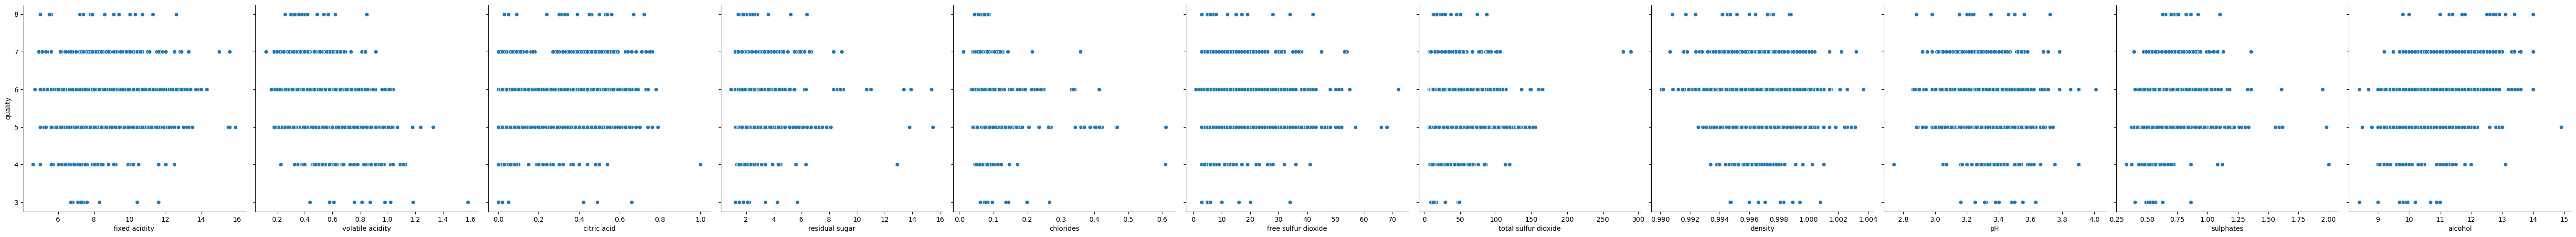

In [3]:
# Create scatterplots of each predictor vs the target variable 'quality'
# y_vars=['quality'] sets 'quality' on the y-axis
# x_vars=cols[:-1] takes all columns except the last one (the predictors) for the x-axis

cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
        'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
        'pH', 'sulphates', 'alcohol', 'quality']

sns.pairplot(df[cols], y_vars=['quality'], x_vars=cols[:-1], height=5)
plt.show()

<span style='background:blue; color:white;'><h1>Scatterplot Insights</h1></span>

<span style='background:blue; color:white;'>Describe what you look for in these scatterplots.</span>

<span style='background:white; color:black;'>What are the two most promising ones to predict the variable you want to know.</span>

<span style='background:white; color:black;'>A scatterplot matrix lets us explore how the chemical properties of wine relate to each other and how they might influence wine quality. We look for patterns such as positive or negative correlations, the strength of these relationships, and any outliers or unusual clusters, while also observing the distribution of each variable along the diagonal. From this analysis, the most promising predictors for wine quality appear to be alcohol and density, which have a strong negative relationship, and fixed acidity, which is moderately related to citric acid. These variables capture key aspects of the wine’s composition and are likely useful for predicting its overall sensory rating.</span>

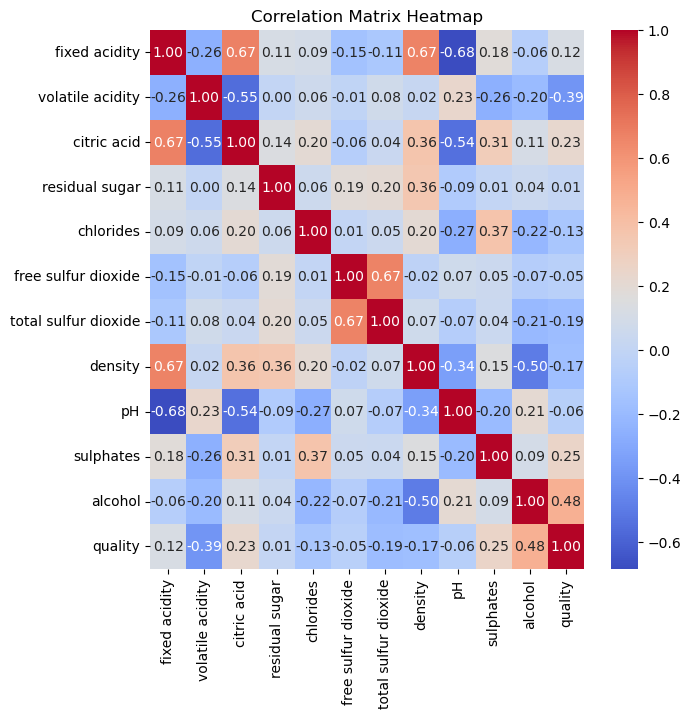

In [4]:
corrMatrix = df.corr()  
plt.figure(figsize=(7,7))  # adjust size 
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

### Bivariate Regression

<span style='background:white; color:black;'>Bivariate regression predicts one variable from another by fitting a straight line to the data. The gradient (slope) shows how much the target changes when the predictor increases, and the constant (intercept) is the value of the target when the predictor is zero. R² tells how well the line fits the points: closer to 1 means a better fit. On a diagram, the gradient controls the line’s steepness, the constant moves it up or down, and R² shows how closely the points follow the line.</span>

Use your **bivariate_regression()** function function (in your *DMS_functions.py*) to perform the bivariate regression between **the first** selected variable and your selected outcome variable.

In [5]:
x = df['alcohol'].tolist()    
y = df['quality'].tolist()
results = dms.bivariate_regression(x, y)
print(results)

{'constant': 1.8749748869971525, 'gradient': 0.36084176533503454, 'det coeff': 0.22673436811275482}


<span style='background:blue; color:white;'>Explain:</span>

1. what the r<sup>2</sup> means
2. what the *gradient* and *constant* mean
3. how the gradient and constant relate to the diagram


<span style='background:blue; color:white;'>Describe if the found regression equation matches the visual representation, and how well the equation represents the data. Add anything else you might notice from the output as well.</span>

Use your **bivariate_regression()** function to perform the bivariate regression between **the second** selected variable and your selected outcome variable.

In [6]:
x2 = df['volatile acidity'].tolist() 
y = df['quality'].tolist() 
results2 = dms.bivariate_regression(x2, y)
print(results2)

{'constant': 6.565745506471788, 'gradient': -1.7614377801126668, 'det coeff': 0.1525353797247485}


<span style='background:blue; color:white;'><h1>Regression Results and Comparison.</h1></span>

<span style='background:white; color:black;'>The regression equation for alcohol is quality = 1.87 + 0.36 × alcohol, which matches the scatterplot showing that higher alcohol generally corresponds to higher quality. Its R² of 0.23 indicates the line explains about 23% of the variation, capturing the general trend but not all the variability. For volatile acidity, the equation is quality = 6.57 - 1.76 × volatile acidity, consistent with the scatterplot showing higher acidity tends to lower quality, but its R² of 0.15 shows it explains less variation than alcohol. Comparing the two, alcohol is a slightly stronger predictor, while volatile acidity has a steeper slope but more scattered points. Overall, both lines reflect the trends seen in the data, but neither variable alone fully explains wine quality.</span>

### Multivariate Regression

<span style='background:white; color:black;'>Multivariate regression predicts one outcome variable using two or more predictor variables at the same time. The model has the form

y = b0 + b1x1 + b2x2

Each gradient (b1, b2) shows how much the outcome changes when that variable increases while the other variable stays constant. The constant (b0) is the predicted value when all predictors are zero. The R² value shows how much of the variation in the outcome is explained by all predictors together.

Compared to bivariate regression, multivariate regression is more complicated because the predictors can affect each other, it is harder to interpret the individual effects, and adding more variables does not always improve the model.</span>

Use your **multivariate_regression()** function function (in your *DMS_functions.py*) to perform the multivariate regression between the two  selected variables and your selected outcome variable.

In [7]:
x1 = df['alcohol'].tolist()
x2 = df['volatile acidity'].tolist()
y = df['quality'].tolist()

multi_x = [x1, x2]

results_multi = dms.multivariate_regression(multi_x, y)
print(results_multi)

{'constant': 3.0954712729137634, 'gradients': [0.3138125156856629, -1.3836357117565534], 'det coeff': 0.31700243279698526}


<span style='background:white; color:black;'>Explain and interpret all the outcome</span>


Compare the result with the results from the bivariate regression section.

<span style='background:white; color:black;'>quality = 3.10 + 0.31 × alcohol − 1.38 × volatile acidity

The positive coefficient for alcohol means that higher alcohol increases predicted quality, while the negative coefficient for volatile acidity shows that higher acidity lowers predicted quality. The R² of 0.32 indicates that this model explains about 32% of the variation in wine quality.
Compared to the bivariate regressions, which had R² values of 0.23 for alcohol and 0.15 for volatile acidity, the multivariate model does a better job of predicting quality. This shows that using both variables together improves the model because it accounts for more of the variation. Overall, the multivariate regression captures the trends in the data better than using just one variable.</span>

## Getting a 80-100

Complete one or more of the sub-sections in here. Each one completed earns +10 on your grade, with a maximum of 100.


<div style="background-color: #fff3cd; border-left: 6px solid #ffa502; padding: 10px;">
  <p style="color: #856404;">
    <p style="color: #856404;">❗❗❗WARNING❗❗❗</p>
    <p style="color: #856404;">The structure of these sub-sections is just a basic skeleton, you will need to add more cells yourself (unlike in the Getting a Pass section)</p>
</div>


<div style="background-color: #fff3cd; border-left: 6px solid #ffa502; padding: 10px;">
  <p style="color: #856404;">
    <p style="color: #856404;">❗❗❗REMINDER❗❗❗</p>
    <p style="color: #856404;">The proper use of AI tools is allowed. With proper is meant you can ask it for clarification, suggestions, etc. but NOT to write the whole section. You must understand everything you write. If there is a suspicion of fraud on this, you could be asked to clarify during class or outside class to check if you understand yourself what you wrote. It will also then be reported to the examboard.</p>
</div>

### Another Type of Regression

There are many different variations on linear regression, e.g. Random Forrest Regression, Support Vector Regression, Neural Network Regression, Logistic Regression, non-linear regression, polynomial regression, etc.

Choose one of these alternatives and explain the theory, then show a step-by-step example, and finally how sklearn can produce the same result.

#### The Theory

*Note* No code cells in this part, but you can of course add as many markdown-cells as you like. Visualizations (i.e. pictures or screenshots) also often work wonders to explain.

#### Worked Out Example

*Note* Show step-by-step how it works. So you need to add code-cells and markdown-cells yourself in this section. Do NOT simply use a library like sklearn, but only Python's own libraries, pandas, pyplot and/or numpy.

#### Using sklearn (or some other library)

*Note* Show in steps how you can use some library (like sklearn) to produce the same result. So you need to add code-cells and markdown-cells yourself in this section. Also perhaps comment on the result compared to the other techniques discussed in class.

### Feature Selection

As warned about in the class notebook simply removing all variables with VIF above a threshold, is NOT a smart strategy. Choosing input features is a whole topic on itself. Approaches are Forward, Backward, Stepwise and Subsets. 

Forward, adds variables one at a time, while backward starts with all and then removes them one at a time. Stepwise is the same but removed or added ones, could be again added or removed in later iterations, and subsets simply brute-forces all possible combination. A nice YouTube tutorial on these is available <a href="https://www.youtube.com/watch?v=-inJu1jHqb8">here</a>. 

Choose one of these and explain the theory, then show a step-by-step example, and finally how sklearn can produce the same result

#### The Theory

*Note* No code cells in this part, but you can of course add as many markdown-cells as you like. Visualizations (i.e. pictures or screenshots) also often work wonders to explain.

#### Worked Out Example

*Note* Show step-by-step how it works. So you need to add code-cells and markdown-cells yourself in this section. Do NOT simply use a library like sklearn, but only Python's own libraries, pandas, pyplot and/or numpy.

#### Using sklearn (or some other library)

*Note* Show in steps how you can use some library (like sklearn) to produce the same result. So you need to add code-cells and markdown-cells yourself in this section. Also perhaps comment on the result compared to the other techniques discussed in class.

### Dive into the Math

Explain the Gradient Descent approach to linear regression, or using Matrix Algebra to obtain the linear regression equation. Explain the theory, then show a step-by-step example, and finally how sklearn can produce the same result



#### The Theory

*Note* No code cells in this part, but you can of course add as many markdown-cells as you like. Visualizations (i.e. pictures or screenshots) also often work wonders to explain.

#### Worked Out Example

*Note* Show step-by-step how it works. So you need to add code-cells and markdown-cells yourself in this section. Do NOT simply use a library like sklearn, but only Python's own libraries, pandas, pyplot and/or numpy.

#### Using sklearn (or some other library)

*Note* Show in steps how you can use some library (like sklearn) to produce the same result. So you need to add code-cells and markdown-cells yourself in this section. Also perhaps comment on the result compared to the other techniques discussed in class.